# ANFIS WBCD — Dự đoán trước khi training (baseline)

Notebook kiểm tra **model `scikit-anfis` dự đoán ra sao trước khi gọi `fit()`** trên Wisconsin Breast Cancer Dataset (UCI original).

Pipeline bám sát `anfis_pca_scikit_anfis_training.ipynb`:
- Tiền xử lý WBCD (loại missing, outlier, chọn 3 feature paper v1/v2/v3)
- Split paper: 200 train / 263 check / 200 test
- Hệ mờ `FS()` với 27 luật chuyên gia + Gaussian MF
- **`predict()` ngay sau khởi tạo model — không huấn luyện**
- (Tuỳ chọn) So sánh với model đã train trong thư mục `models/`

In [6]:
import warnings
warnings.filterwarnings("ignore")

import json
import itertools
import pickle
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

from skanfis import scikit_anfis
from skanfis.fs import FS, LinguisticVariable, GaussianFuzzySet

print("Torch:", torch.__version__)

Torch: 2.12.0+cpu


In [7]:
# 1) Load WBCD goc (UCI Breast Cancer Wisconsin Original)
uci_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"

cols = [
    "sample_code_number",
    "clump_thickness",
    "uniformity_of_cell_size",
    "uniformity_of_cell_shape",
    "marginal_adhesion",
    "single_epithelial_cell_size",
    "bare_nuclei",
    "bland_chromatin",
    "normal_nucleoli",
    "mitoses",
    "class",
]

df = pd.read_csv(uci_url, header=None, names=cols)
df = df.replace("?", np.nan).dropna().copy()
df["bare_nuclei"] = df["bare_nuclei"].astype(int)
df["target"] = (df["class"] == 4).astype(int)

feature_cols = [
    "clump_thickness",
    "uniformity_of_cell_size",
    "uniformity_of_cell_shape",
    "marginal_adhesion",
    "single_epithelial_cell_size",
    "bare_nuclei",
    "bland_chromatin",
    "normal_nucleoli",
    "mitoses",
]

feature_name_map = {
    "clump_thickness": "Clump Thickness",
    "uniformity_of_cell_size": "Uniformity of Cell Size",
    "uniformity_of_cell_shape": "Uniformity of Cell Shape",
    "marginal_adhesion": "Marginal Adhesion",
    "single_epithelial_cell_size": "Single Epithelial Cell Size",
    "bare_nuclei": "Bare Nuclei",
    "bland_chromatin": "Bland Chromatin",
    "normal_nucleoli": "Normal Nucleoli",
    "mitoses": "Mitoses",
}

X = df[feature_cols].values.astype(np.float32)
y = df["target"].values.astype(np.float32)

print("Dataset shape:", X.shape)
print("Class balance (malignant rate):", round(float(y.mean()), 4))

Dataset shape: (683, 9)
Class balance (malignant rate): 0.3499


In [8]:
# 2) PCA + chon 3 feature paper + split 200/263/200

OUTLIER_STD_MULTIPLIER = 2.5
y_all = y.astype(int)

data_center = X.mean(axis=0)
euclidean_distances = np.linalg.norm(X - data_center, axis=1)
outlier_threshold = euclidean_distances.mean() + OUTLIER_STD_MULTIPLIER * euclidean_distances.std()
outlier_mask = euclidean_distances > outlier_threshold
keep_mask = ~outlier_mask

X_clean = X[keep_mask]
y_clean = y_all[keep_mask]
df_clean = df.iloc[keep_mask].reset_index(drop=True)

print(f"Outlier loai bo: {int(outlier_mask.sum())} mau, con lai: {len(X_clean)}")

scaler = StandardScaler()
X_norm = scaler.fit_transform(X_clean).astype(np.float32)

pca_full = PCA(n_components=9, random_state=42)
pca_full.fit(X_norm)

PAPER_TOP3_FEATURES = [
    "clump_thickness",
    "uniformity_of_cell_size",
    "uniformity_of_cell_shape",
]
selected_feature_names = PAPER_TOP3_FEATURES
selected_idx = [feature_cols.index(c) for c in selected_feature_names]
X_selected = X_norm[:, selected_idx].astype(np.float32)

n_drop = len(X_selected) - 663
centroid_benign = X_selected[y_clean == 0].mean(axis=0)
centroid_malignant = X_selected[y_clean == 1].mean(axis=0)
dist_to_benign = np.linalg.norm(X_selected - centroid_benign, axis=1)
dist_to_malignant = np.linalg.norm(X_selected - centroid_malignant, axis=1)
own_dist = np.where(y_clean == 0, dist_to_benign, dist_to_malignant)
other_dist = np.where(y_clean == 0, dist_to_malignant, dist_to_benign)
quality_score = other_dist - own_dist

drop_idx = np.argsort(quality_score)[:n_drop]
quality_keep_mask = np.ones(len(X_selected), dtype=bool)
quality_keep_mask[drop_idx] = False

indices = np.where(quality_keep_mask)[0]
X_663 = X_selected[indices]
y_663 = y_clean[indices]
df_663 = df_clean.iloc[indices].reset_index(drop=True)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_663, y_663, train_size=200, random_state=42, stratify=y_663,
)
X_check, X_test, y_check, y_test = train_test_split(
    X_temp, y_temp, train_size=263, random_state=42, stratify=y_temp,
)

idx_train, idx_temp = train_test_split(
    np.arange(len(X_663)), train_size=200, random_state=42, stratify=y_663,
)
idx_check, idx_test = train_test_split(
    idx_temp, train_size=263, random_state=42, stratify=y_663[idx_temp],
)

print("3 features ANFIS:", selected_feature_names)
print("Split (train/check/test):", X_train.shape, X_check.shape, X_test.shape)

Outlier loai bo: 18 mau, con lai: 665
3 features ANFIS: ['clump_thickness', 'uniformity_of_cell_size', 'uniformity_of_cell_shape']
Split (train/check/test): (200, 3) (263, 3) (200, 3)


In [9]:
# 3) Dung he mo FS + tao model ANFIS — CHUA fit()

FS_VAR_NAMES = {
    "clump_thickness": "ClumpThickness",
    "uniformity_of_cell_size": "CellSize",
    "uniformity_of_cell_shape": "CellShape",
}
FS_DISPLAY_NAMES = {v: feature_name_map[k] for k, v in FS_VAR_NAMES.items()}
LINGUISTIC_TERMS = ("low", "medium", "high")

fs = FS()
mf_init_log = []

for i, feat_col in enumerate(selected_feature_names):
    fs_var = FS_VAR_NAMES[feat_col]
    col = X_train[:, i]
    col_min, col_max = float(col.min()), float(col.max())
    centers = np.linspace(col_min, col_max, 3).tolist()
    sigma = max((col_max - col_min) / 3.0, 1e-3)

    mf_low = GaussianFuzzySet(mu=centers[0], sigma=sigma, term="low")
    mf_med = GaussianFuzzySet(mu=centers[1], sigma=sigma, term="medium")
    mf_high = GaussianFuzzySet(mu=centers[2], sigma=sigma, term="high")
    fs.add_linguistic_variable(
        fs_var,
        LinguisticVariable([mf_low, mf_med, mf_high], concept=FS_DISPLAY_NAMES[fs_var]),
    )
    mf_init_log.append({
        "var": FS_DISPLAY_NAMES[fs_var],
        "mu": [round(c, 4) for c in centers],
        "sigma": round(sigma, 4),
    })

fs.set_crisp_output_value("benign", 0)
fs.set_crisp_output_value("malignant", 1)


def expert_diagnosis(clump_term, size_term, shape_term):
    score = {"low": 0, "medium": 1, "high": 2}
    v = [score[clump_term], score[size_term], score[shape_term]]
    high_count = sum(x == 2 for x in v)
    if high_count >= 2:
        return "malignant"
    if sum(v) <= 2:
        return "benign"
    if v[0] == 2:
        return "malignant"
    if sum(v) >= 4:
        return "malignant"
    return "benign"


EXPERT_RULES = []
for ct, cs, csh in itertools.product(LINGUISTIC_TERMS, repeat=3):
    diagnosis = expert_diagnosis(ct, cs, csh)
    EXPERT_RULES.append(
        f"IF (ClumpThickness IS {ct}) AND (CellSize IS {cs}) AND (CellShape IS {csh}) "
        f"THEN (Diagnosis IS {diagnosis})"
    )
fs.add_rules(EXPERT_RULES)

model = scikit_anfis(
    fs,
    description="WBCD_Pretrain_Baseline",
    epoch=300,
    hybrid=True,
    label="c",
    zerotype=True,
)

# zerotype=True: consequent chi la hang so 0/1 tu THEN luat chuyen gia.
# scikit-anfis gan fs.coeff shape (27,4) — sai shape cho zerotype (can 27x1x1).
# Chi lay cot cuoi (crisp output) va reshape truoc khi predict.
with torch.no_grad():
    rule_constants = torch.tensor(
        fs.coeff[:, -1], dtype=torch.float32
    ).reshape(model.num_rules, model.num_out, 1)
    model.layer["consequent"].coeff = rule_constants

print(f"He mo FS: {len(EXPERT_RULES)} luat (grid 3^3)")
print("Khoi tao Gaussian MF (tu tap train):")
for item in mf_init_log:
    print(f"  {item['var']}: mu={item['mu']}, sigma={item['sigma']}")
print("\nModel da khoi tao — CHUA goi fit()")
print("Consequent zerotype (5 luat dau):", model.coeff[:5, 0, 0].tolist())

 * Detected Sugeno model type
He mo FS: 27 luat (grid 3^3)
Khoi tao Gaussian MF (tu tap train):
  Clump Thickness: mu=[-1.2045, 0.417, 2.0384], sigma=1.081
  Uniformity of Cell Size: mu=[-0.6809, 0.8781, 2.4372], sigma=1.0394
  Uniformity of Cell Shape: mu=[-0.7237, 0.8793, 2.4824], sigma=1.0687

Model da khoi tao — CHUA goi fit()
Consequent zerotype (5 luat dau): [0.0, 0.0, 0.0, 0.0, 0.0]


In [10]:
# 4) Predict TRUOC training + danh gia metric
# Luu y: model.predict() cua scikit-anfis goi load('tmp.pkl') — khong dung cho model chua train.
# Dung forward truc tiep thay the.

def to_binary(pred):
    pred = np.asarray(pred).reshape(-1)
    return np.clip(np.round(pred), 0, 1).astype(int)


def predict_continuous(model, X):
    """Score lien tuc (khong goi model.load)."""
    X_t = torch.from_numpy(np.asarray(X, dtype=np.float32)).float()
    model.eval()
    model.is_training = False
    with torch.no_grad():
        scores = model(X_t)
    return scores.numpy().reshape(-1)


def predict_binary(model, X):
    return to_binary(predict_continuous(model, X))


def evaluate_split(name, y_true, y_pred, y_score=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_score if y_score is not None else y_pred)
    except ValueError:
        auc = np.nan

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n{name} — PRE-TRAIN baseline")
    print("- Accuracy :", round(acc, 4))
    print("- Precision:", round(prec, 4))
    print("- Recall   :", round(rec, 4))
    print("- F1-score :", round(f1, 4))
    print("- ROC-AUC  :", round(auc, 4) if not np.isnan(auc) else "nan")
    print("- Confusion matrix:\n", cm)

    return {
        "split": name,
        "phase": "pre_train",
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1_score": float(f1),
        "roc_auc": None if np.isnan(auc) else float(auc),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "support": int(len(y_true)),
    }


splits = {
    "TRAIN": (X_train, y_train),
    "CHECK": (X_check, y_check),
    "TEST": (X_test, y_test),
}

pretrain_results = {}
pretrain_metrics = []

for name, (X_split, y_split) in splits.items():
    y_score = predict_continuous(model, X_split)
    y_pred = predict_binary(model, X_split)
    pretrain_results[name] = {
        "y_true": y_split.astype(int),
        "y_pred": y_pred,
        "y_score": y_score,
    }
    pretrain_metrics.append(
        evaluate_split(name, y_split.astype(int), y_pred, y_score)
    )

pretrain_metrics_df = pd.DataFrame(pretrain_metrics)
display(pretrain_metrics_df)


TRAIN — PRE-TRAIN baseline
- Accuracy : 0.83
- Precision: 0.9714
- Recall   : 0.5075
- F1-score : 0.6667
- ROC-AUC  : 0.9914
- Confusion matrix:
 [[132   1]
 [ 33  34]]

CHECK — PRE-TRAIN baseline
- Accuracy : 0.9163
- Precision: 0.9851
- Recall   : 0.7586
- F1-score : 0.8571
- ROC-AUC  : 0.9843
- Confusion matrix:
 [[175   1]
 [ 21  66]]

TEST — PRE-TRAIN baseline
- Accuracy : 0.88
- Precision: 1.0
- Recall   : 0.6418
- F1-score : 0.7818
- ROC-AUC  : 0.9838
- Confusion matrix:
 [[133   0]
 [ 24  43]]


,split,phase,accuracy,precision,recall,f1_score,roc_auc,tn,fp,fn,tp,support
0,TRAIN,pre_train,0.83000,0.971429,0.507463,0.666667,0.991359,132,1,33,34,200
1,CHECK,pre_train,0.91635,0.985075,0.758621,0.857143,0.984326,175,1,21,66,263
2,TEST,pre_train,0.88000,1.000000,0.641791,0.781818,0.983784,133,0,24,43,200


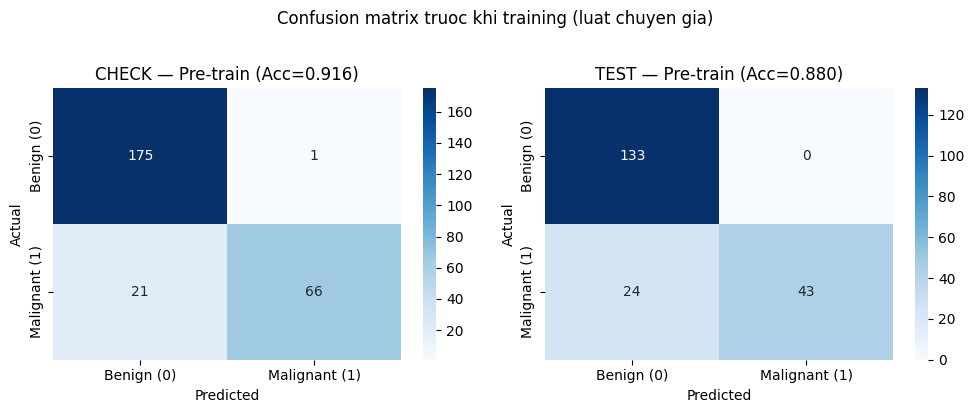

In [11]:
# 5) Confusion matrix heatmap (check + test)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, split_name in zip(axes, ["CHECK", "TEST"]):
    y_true = pretrain_results[split_name]["y_true"]
    y_pred = pretrain_results[split_name]["y_pred"]
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["Benign (0)", "Malignant (1)"],
        yticklabels=["Benign (0)", "Malignant (1)"],
    )
    acc = accuracy_score(y_true, y_pred)
    ax.set_title(f"{split_name} — Pre-train (Acc={acc:.3f})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion matrix truoc khi training (luat chuyen gia)", y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# 6) Phan tich mau du doan sai (test set)

y_true_t = pretrain_results["TEST"]["y_true"]
y_pred_t = pretrain_results["TEST"]["y_pred"]
y_score_t = pretrain_results["TEST"]["y_score"]

wrong_mask = y_true_t != y_pred_t
wrong_df = pd.DataFrame({
    "sample_code_number": df_663.iloc[idx_test]["sample_code_number"].values[wrong_mask],
    "y_true": y_true_t[wrong_mask],
    "y_pred": y_pred_t[wrong_mask],
    "score": np.round(y_score_t[wrong_mask], 4),
    "clump_thickness": X_test[wrong_mask, 0],
    "uniformity_of_cell_size": X_test[wrong_mask, 1],
    "uniformity_of_cell_shape": X_test[wrong_mask, 2],
})

print(f"Test set: {wrong_mask.sum()} mau du doan sai / {len(y_true_t)}")
if len(wrong_df):
    display(wrong_df.head(15))
else:
    print("Khong co mau sai.")

Test set: 24 mau du doan sai / 200


,sample_code_number,y_true,y_pred,score,clump_thickness,uniformity_of_cell_size,uniformity_of_cell_shape
0,1176881,1,0,0.3805,0.957444,0.704894,-0.011249
1,1123061,1,0,0.4153,0.597115,2.437174,-0.367480
2,1185609,1,0,0.1093,-0.483869,0.358439,0.701212
3,1084139,1,0,0.1828,0.597115,0.011983,-0.367480
4,1226012,1,0,0.0389,-0.123541,-0.680929,-0.723711
5,832567,1,0,0.0694,-0.123541,-0.334473,-0.011249
6,1118039,1,0,0.1616,0.236787,0.011983,0.344981
7,1076352,1,0,0.1427,-0.483869,1.051350,0.344981
8,1041801,1,0,0.1362,0.236787,0.011983,-0.011249
9,1047630,1,0,0.4661,0.957444,0.358439,1.057442


In [13]:
# 7) (Tuỳ chọn) So sanh voi model da train

COMPARE_STAMP = "20260621_174830"
RUN_TAG = "paperstyle_pca_feature_select"
models_dir = Path("models")
trained_model_path = models_dir / f"{COMPARE_STAMP}_{RUN_TAG}_best_model.pkl"

comparison_rows = []

if trained_model_path.exists():
    trained_model = scikit_anfis(
        fs,
        description="WBCD_PostTrain_Compare",
        epoch=300,
        hybrid=True,
        label="c",
        zerotype=True,
    )
    trained_model.load(str(trained_model_path))
    trained_model.eval()
    trained_model.is_training = False
    print(f"Da load model da train: {trained_model_path.name}")

    for name, (X_split, y_split) in splits.items():
        y_score_post = predict_continuous(trained_model, X_split)
        y_pred_post = predict_binary(trained_model, X_split)
        post_metrics = evaluate_split(f"{name} (POST-TRAIN)", y_split.astype(int), y_pred_post, y_score_post)

        pre_row = next(r for r in pretrain_metrics if r["split"] == name)
        comparison_rows.append({
            "split": name,
            "pre_train_accuracy": pre_row["accuracy"],
            "post_train_accuracy": post_metrics["accuracy"],
            "delta_accuracy": post_metrics["accuracy"] - pre_row["accuracy"],
            "pre_train_f1": pre_row["f1_score"],
            "post_train_f1": post_metrics["f1_score"],
            "delta_f1": post_metrics["f1_score"] - pre_row["f1_score"],
        })

    comparison_df = pd.DataFrame(comparison_rows)
    print("\n--- So sanh Pre-train vs Post-train ---")
    display(comparison_df)
else:
    print(f"Khong tim thay model da train: {trained_model_path}")
    print("Bo qua buoc so sanh.")

Da load model da train: 20260621_174830_paperstyle_pca_feature_select_best_model.pkl

TRAIN (POST-TRAIN) — PRE-TRAIN baseline
- Accuracy : 0.985
- Precision: 0.9848
- Recall   : 0.9701
- F1-score : 0.9774
- ROC-AUC  : 0.9987
- Confusion matrix:
 [[132   1]
 [  2  65]]

CHECK (POST-TRAIN) — PRE-TRAIN baseline
- Accuracy : 0.9392
- Precision: 0.8989
- Recall   : 0.9195
- F1-score : 0.9091
- ROC-AUC  : 0.9728
- Confusion matrix:
 [[167   9]
 [  7  80]]

TEST (POST-TRAIN) — PRE-TRAIN baseline
- Accuracy : 0.935
- Precision: 0.8971
- Recall   : 0.9104
- F1-score : 0.9037
- ROC-AUC  : 0.9724
- Confusion matrix:
 [[126   7]
 [  6  61]]

--- So sanh Pre-train vs Post-train ---


,split,pre_train_accuracy,post_train_accuracy,delta_accuracy,pre_train_f1,post_train_f1,delta_f1
0,TRAIN,0.83000,0.985000,0.155000,0.666667,0.977444,0.310777
1,CHECK,0.91635,0.939163,0.022814,0.857143,0.909091,0.051948
2,TEST,0.88000,0.935000,0.055000,0.781818,0.903704,0.121886


In [14]:
# 8) Export ket qua baseline

stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = Path("models")
out_dir.mkdir(exist_ok=True)

metrics_path = out_dir / f"{stamp}_pretrain_baseline_metrics.json"
metrics_csv_path = out_dir / f"{stamp}_pretrain_baseline_metrics.csv"
pred_csv_path = out_dir / f"{stamp}_pretrain_baseline_predictions.csv"

export_payload = {
    "created_at": stamp,
    "dataset": "UCI WBCD original",
    "phase": "pre_train_baseline",
    "trained": False,
    "selected_features": selected_feature_names,
    "num_rules": len(EXPERT_RULES),
    "splits": {m["split"]: m for m in pretrain_metrics},
}

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(export_payload, f, indent=2, ensure_ascii=False)

pretrain_metrics_df.to_csv(metrics_csv_path, index=False)

pred_rows = []
split_index_map = {"TRAIN": idx_train, "CHECK": idx_check, "TEST": idx_test}
for split_name, idxs in split_index_map.items():
    res = pretrain_results[split_name]
    for j, global_idx in enumerate(idxs):
        pred_rows.append({
            "sample_code_number": int(df_663.iloc[global_idx]["sample_code_number"]),
            "split": split_name,
            "y_true": int(res["y_true"][j]),
            "y_pred": int(res["y_pred"][j]),
            "score": float(res["y_score"][j]),
        })

pred_df = pd.DataFrame(pred_rows)
pred_df.to_csv(pred_csv_path, index=False)

print("Da luu:")
print("-", metrics_path)
print("-", metrics_csv_path)
print("-", pred_csv_path)

Da luu:
- models\20260624_071649_pretrain_baseline_metrics.json
- models\20260624_071649_pretrain_baseline_metrics.csv
- models\20260624_071649_pretrain_baseline_predictions.csv
